# InceptionTime — Aircraft Maintenance Prediction

**Dataset:** NGAFID — 28,935 Cessna 172 flights, 15 sensor channels at 1 Hz  
**Task:** Binary classification — predict whether a flight occurs within 2 days of an unplanned maintenance event  
**Target column:** `rul_2d` (0 = at-risk, 1 = safe)

---

## What this notebook does

1. Loads the shared, pre-processed flight sequences and labels.
2. Builds an InceptionTime model — a multi-scale 1-D convolutional network for time series.
3. Trains one model per random seed and averages their predictions into an ensemble.
4. Evaluates on the held-out test set with ROC-AUC, PR-AUC, and several decision thresholds.
5. Saves each flight's predicted probability of being at-risk to a CSV for ensembling with other models.

## Configuration

| Setting | Value | Meaning |
|---------|-------|---------|
| Architecture | InceptionTime (multi-scale 1-D CNN) | reads short, medium, and long temporal patterns at once |
| Filters per block (`nf`) | 64 | 256 output channels per inception block |
| Depth | 6 modules | a residual shortcut every 3 layers |
| Dropout | 0.20 | applied after the residual connections and before the final linear layer |
| Peak learning rate | 3 × 10⁻⁴ | OneCycleLR warms up then anneals over 30 epochs |
| Weight decay | 1 × 10⁻⁴ | L2 regularisation via Adam |
| Loss | class-weighted CrossEntropy | at-risk class up-weighted by inverse frequency |

The metrics produced by a run are printed in Section 5.

## 0. Environment Patch


In [1]:
import sklearn.utils.fixes as _sf
from types import ModuleType
import sys

# Kaggle environment patch
for _fn in ['_sparse_min_max', '_get_additional_lbfgs_options_dict']:
    if not hasattr(_sf, _fn):
        setattr(_sf, _fn, lambda *a, **kw: None)

for _mod in ['sklearn.utils._test_common', 'sklearn.utils._test_common.instance_generator']:
    if _mod not in sys.modules:
        _m = ModuleType(_mod); _m.__spec__ = None
        sys.modules[_mod] = _m

print("Environment patch applied")

Environment patch applied


## 1. Imports and Reproducibility

All random seeds are fixed **before** importing libraries that use randomness.  
`cudnn.deterministic = True` and `benchmark = False` disable non-deterministic GPU kernel selection,  
ensuring identical results across runs with the same seed.

In [2]:
# Set seed before library initialises RNG 
SEED = 42
import random
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True   # reproducible GPU ops
torch.backends.cudnn.benchmark     = False  # disable auto-tuner (non-deterministic)

# Standard imports 
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR
import gc

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, precision_recall_curve
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'Seed    : {SEED}')

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
Seed    : 42


## 2. InceptionTime Architecture

InceptionTime is a multi-scale 1-D convolutional network for time-series classification.

**InceptionModule** — the core building block.  
Three parallel convolutions (kernel sizes 39, 19, 9 timesteps) plus a max-pool path run on the
same input at once. Their outputs are concatenated, so the module reads patterns at several
temporal scales simultaneously. A 1×1 bottleneck convolution shrinks the channel count before
the parallel paths to keep the parameter count manageable.

**InceptionBlock** — stacks several InceptionModules.  
Every 3 layers a residual shortcut adds the block's input back to its output, which lets gradients
reach earlier layers and keeps deep stacks trainable. Dropout is applied after each residual merge.

**InceptionTime** — the full model.  
`backbone` (InceptionBlock) → masked pooling over time → `Dropout` → `Linear`.  
Each flight is left-padded with zeros to a shared length. The pooling step uses a mask so it
averages and takes the maximum over the real (non-padded) timesteps only, ignoring the padding.
The masked average and masked maximum are concatenated before the final linear layer, which is
why that layer sees twice as many channels as the backbone outputs.  
Input shape: `(batch, 15 channels, 9212 timesteps)`. Output: 2 logits (at-risk, safe).

In [3]:
class InceptionModule(nn.Module):
    """Single inception block: bottleneck -> three parallel convolutions + max-pool path -> BN + ReLU."""

    def __init__(self, c_in, nb_filters=32, ks=(39, 19, 9), bottleneck=True):
        super().__init__()
        # Bottleneck reduces channels before the parallel convolutions (used from layer 2 onward)
        bn_c = min(nb_filters, c_in)
        self.bottleneck = nn.Conv1d(c_in, bn_c, 1, bias=False) if bottleneck and c_in > 1 else None
        in_c = bn_c if self.bottleneck else c_in

        # Three parallel convolutions with different kernel sizes
        self.convs = nn.ModuleList([
            nn.Conv1d(in_c, nb_filters, k, padding=k // 2, bias=False) for k in ks
        ])

        # Max-pool path captures local extrema without learning
        self.mp_conv = nn.Sequential(
            nn.MaxPool1d(3, stride=1, padding=1),
            nn.Conv1d(c_in, nb_filters, 1, bias=False)
        )

        # Batch norm + ReLU applied to the concatenated output of all four paths
        self.bn    = nn.BatchNorm1d(nb_filters * (len(ks) + 1))
        self.relu  = nn.ReLU()
        self.out_c = nb_filters * (len(ks) + 1)   # output channels = 4 * nb_filters

    def forward(self, x):
        x_in = self.bottleneck(x) if self.bottleneck else x
        out  = [conv(x_in) for conv in self.convs] + [self.mp_conv(x)]
        return self.relu(self.bn(torch.cat(out, dim=1)))


class InceptionBlock(nn.Module):
    """Stack of InceptionModules with residual connections every 3 layers and dropout."""

    def __init__(self, c_in, nb_filters=32, depth=6, ks=(39, 19, 9), dropout=0.2):
        super().__init__()
        self.layers = nn.ModuleList()
        self.res    = nn.ModuleList()   # residual projection (None if no shortcut at this layer)
        self.drops  = nn.ModuleList()
        self.relu   = nn.ReLU()
        c = c_in
        for i in range(depth):
            mod = InceptionModule(c, nb_filters, ks, bottleneck=(i > 0))
            self.layers.append(mod)
            if (i + 1) % 3 == 0:
                # Residual shortcut: 1x1 conv to match channel dimensions, then BN
                self.res.append(nn.Sequential(
                    nn.Conv1d(c_in, mod.out_c, 1, bias=False),
                    nn.BatchNorm1d(mod.out_c)
                ))
                self.drops.append(nn.Dropout(dropout))
            else:
                self.res.append(None)
                self.drops.append(None)
            c = mod.out_c
            if (i + 1) % 3 == 0:
                c_in = c   # update residual input channels for the next group
        self.out_c = c

    def forward(self, x):
        res_x = x
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if self.res[i] is not None:
                x = self.relu(x + self.res[i](res_x))   # residual merge + activation
                x = self.drops[i](x)
                res_x = x
        return x


class InceptionTime(nn.Module):
    """
    Full InceptionTime classifier.
    Input:  (batch, channels, timesteps)
    Output: (batch, n_classes) logits
    """

    def __init__(self, c_in, c_out, nf=64, depth=6, ks=(39, 19, 9), dropout=0.2):
        super().__init__()
        self.backbone = InceptionBlock(c_in, nf, depth, ks, dropout)
        self.dropout  = nn.Dropout(dropout)
        # Pooling concatenates a masked average and a masked maximum over time,
        # so the linear layer receives twice the backbone's output channels.
        self.fc = nn.Linear(self.backbone.out_c * 2, c_out)

    def forward(self, x):
        # Each flight is left-padded with zeros so all sequences share one length.
        # This mask marks the real timesteps: True where any channel is non-zero,
        # False where every channel is zero (padding). Shape: (batch, 1, timesteps).
        mask = (x.abs().sum(dim=1, keepdim=True) > 0)

        feat = self.backbone(x).float()         # (batch, channels, timesteps)
        mask = mask.float()

        # Masked average: sum features over real timesteps and divide by their count,
        # so the zero-padding does not pull the average toward zero.
        summed = (feat * mask).sum(dim=2)
        count  = mask.sum(dim=2).clamp(min=1.0)
        avg    = summed / count

        # Masked maximum: set padded positions to -inf so they are never selected.
        mx = feat.masked_fill(mask == 0, float('-inf')).max(dim=2).values

        pooled = torch.cat([avg, mx], dim=1)    # (batch, channels * 2)
        return self.fc(self.dropout(pooled))


# Quick sanity check: verify output shape before loading data 
_x = torch.randn(4, 15, 9212)
_m = InceptionTime(c_in=15, c_out=2, nf=64, depth=6, dropout=0.2)
assert _m(_x).shape == (4, 2), "Unexpected output shape"
print(f'Architecture check passed — parameters: {sum(p.numel() for p in _m.parameters()):,}')
del _x, _m

Architecture check passed — parameters: 1,675,778


## 3. Data Loading and Preparation

The shared preprocessing pipeline produces three files from EDA pipeline:

| File | Shape | Description |
|------|-------|-------------|
| `sequences.npy` | (19540, 9212, 15) float16 | RobustScaled sensor time series, left-zero-padded to equal length |
| `labels.csv` | 19540 rows | `rul_2d` target column + shared `split` column (70 / 15 / 15 %) |
| `seq_indices.npy` | (19540,) int | Maps each row of `sequences.npy` to its **Master Index** (flight ID) |

### Memory strategy

`sequences.npy` is stored as float16 (5.4 GB). A naive float32 load would immediately double peak RAM to 10.8 GB. To limit RAM usage, we:

1. Load each split as float16 (~0.8–3.8 GB per split)
2. Transpose from `(N, timesteps, channels)` → `(N, channels, timesteps)` and convert to float32 in `astype(np.float32, order='C')` call 
3. Free the float16 source immediately after each split


In [4]:
# File paths
BASE = "/kaggle/input/datasets/kimberlybertoli/aircraft-pipeline"

labels   = pd.read_csv(f"{BASE}/labels.csv", index_col="Master Index")

# mmap_mode="r" maps the file into virtual memory without loading it all at once
# the OS reads individual pages only when they are accessed during indexing 
X_full   = np.load(f"{BASE}/sequences.npy",   mmap_mode="r")   
idx_full = np.load(f"{BASE}/seq_indices.npy")                  

# Align labels and split assignments to the sequence rows
y_full    = labels.loc[idx_full, "rul_2d"].values
split_col = labels.loc[idx_full, "split"].values

print(f"Sequences  : {X_full.shape}  dtype={X_full.dtype}")
print(f"Labels     : {y_full.shape}  classes={np.unique(y_full)}")
print(f"Class dist : 0 (at-risk)={int((y_full==0).sum()):,}  1 (safe)={int((y_full==1).sum()):,}")
print(f"Split dist : { {s: int((split_col==s).sum()) for s in ['train','val','test']} }")

Sequences  : (19540, 9212, 15)  dtype=float16
Labels     : (19540,)  classes=[0 1]
Class dist : 0 (at-risk)=7,889  1 (safe)=11,651
Split dist : {'train': 13678, 'val': 2931, 'test': 2931}


In [5]:
# Split into train / val / test
# Arrays are kept as float16 here
X_train = X_full[split_col == "train"]  
y_train = y_full[split_col == "train"]
X_val   = X_full[split_col == "val"]     
y_val   = y_full[split_col == "val"]
X_test  = X_full[split_col == "test"]   
y_test  = y_full[split_col == "test"]
del X_full; gc.collect()   # release the memory-mapped file handle

print(f"Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")
print(f"Train class dist — 0 (at-risk): {int((y_train==0).sum()):,}  1 (safe): {int((y_train==1).sum()):,}")

# Sanity check
# Sequences are already RobustScaled - no further normalisation needed
# dtype=np.float32 prevents float16 accumulation error when summing billions of values
print(f"  Sanity check (training set):")
print(f"  mean  : {X_train.mean(dtype=np.float32):.4f}  (expect near 0 after RobustScaling)")
print(f"  NaNs  : {np.isnan(X_train).sum()}")
print(f"  non-zero rows: {int((X_train != 0).any(axis=(1,2)).sum())} / {len(X_train)}")

Train : 13,678  |  Val : 2,931  |  Test : 2,931
Train class dist — 0 (at-risk): 5,522  1 (safe): 8,156
  Sanity check (training set):
  mean  : -0.0560  (expect near 0 after RobustScaling)
  NaNs  : 0
  non-zero rows: 13678 / 13678


In [6]:
# Transpose and convert to contiguous float32
# PyTorch Conv1d expects (batch, channels, timesteps); the pipeline gives (N, timesteps, channels).
#
# .transpose(0, 2, 1) alone returns a non-contiguous view
#
# .astype(np.float32, order='C') transposes and converts dtype in a single pass,
# producing a C-contiguous float32 array directly from the float16 view

# Each split is processed then immediately freed to limit peak RAM to ~13 GB.

_n0 = int((y_train == 0).sum())   
_n1 = int((y_train == 1).sum()) 
y_train_fit = y_train

X_tr = X_train.transpose(0, 2, 1).astype(np.float32, order='C')   # (N_tr, 15, 9212) contiguous
del X_train; gc.collect()

X_vl = X_val.transpose(0, 2, 1).astype(np.float32, order='C')     # (N_vl, 15, 9212) contiguous
del X_val; gc.collect()

print(f"Class counts — 0 (at-risk): {_n0:,}  |  1 (safe): {_n1:,}")
print(f"Imbalance ratio: {max(_n0,_n1)/min(_n0,_n1):.2f}x")
print(f"X_tr strides  : {X_tr.strides}  ({'C-contiguous' if X_tr.flags['C_CONTIGUOUS'] else 'NOT contiguous'})")

# Build DataLoaders
# Wraps numpy arrays in PyTorch Tensors and creates batched iterators. Training uses shuffle=True; val/test use shuffle=False.

def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(
        torch.from_numpy(X).float(),
        torch.from_numpy(y.astype(np.int64))
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)

train_dl = make_loader(X_tr, y_train_fit, batch_size=32, shuffle=True)
val_dl   = make_loader(X_vl, y_val,       batch_size=64, shuffle=False)

print(f" Train batches : {len(train_dl)}  |  Val batches : {len(val_dl)}")
del X_tr, X_vl; gc.collect()   

Class counts — 0 (at-risk): 5,522  |  1 (safe): 8,156
Imbalance ratio: 1.48x
X_tr strides  : (552720, 36848, 4)  (C-contiguous)
 Train batches : 428  |  Val batches : 46


0

## 4. Model Training

One model is trained for each seed in `SEEDS`. Every model starts from a different random
initialisation, trains independently, and keeps the checkpoint with the best validation ROC-AUC.
Those checkpoints form an ensemble whose predicted probabilities are averaged in later sections;
with a single seed the ensemble is just that one model.

| Technique | What it does |
|-----------|--------------|
| Class-weighted loss | At-risk flights are the minority class. The loss up-weights them by inverse frequency so both classes matter equally. |
| OneCycleLR | The learning rate warms up to its peak, then decreases down over the 30 epochs. |
| Mixed precision (AMP) | Forward and backward passes run in float16 for speed; a `GradScaler` rescales the loss so small gradients do not underflow to zero. |
| Gradient clipping | Caps the gradient norm at 1.0 each step to keep updates stable. |
| Early stopping | Training stops if validation ROC-AUC does not improve for 7 epochs, and the best checkpoint is restored. |

In [7]:
# Training configuration 
EPOCHS       = 30
LR_MAX       = 3e-4
PATIENCE     = 7          # stop a run after this many epochs without val ROC gain
DROPOUT      = 0.2
WEIGHT_DECAY = 1e-4

# One model is trained per seed; their predicted probabilities are averaged into the final prediction
SEEDS = [42]

# Class weights
# The at-risk class is the minority, so it is up-weighted by its inverse frequency
class_weight = torch.tensor([_n1 / _n0, 1.0], dtype=torch.float32).to(device)
print(f"Class weights — at-risk: {class_weight[0]:.3f}  safe: {class_weight[1]:.3f}")

def build_model():
    """Create a fresh model, loss, optimizer, and LR scheduler for one training run."""
    model     = InceptionTime(c_in=15, c_out=2, nf=64, depth=6, dropout=DROPOUT).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_MAX, weight_decay=WEIGHT_DECAY)
    # OneCycleLR steps once per batch, so total_steps = batches_per_epoch * epochs
    scheduler = OneCycleLR(optimizer, max_lr=LR_MAX,
                           steps_per_epoch=len(train_dl), epochs=EPOCHS)
    return model, criterion, optimizer, scheduler

_tmp = InceptionTime(c_in=15, c_out=2, nf=64, depth=6, dropout=DROPOUT)
print(f"Parameters per model: {sum(p.numel() for p in _tmp.parameters()):,}")
del _tmp

Class weights — at-risk: 1.477  safe: 1.000
Parameters per model: 1,675,778


In [8]:
# Train model

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

best_states = []   # one best-checkpoint state_dict per seed

for run_i, seed in enumerate(SEEDS, 1):
    set_seed(seed)
    model, criterion, optimizer, scheduler = build_model()
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    best_roc, best_state, patience_ctr = 0.0, None, 0
    print(f"\n=== Model {run_i}/{len(SEEDS)} (seed {seed}) ===")
    print(f"{'Epoch':>5}  {'train_loss':>10}  {'val_loss':>8}  {'val_roc':>7}")
    print('-' * 40)

    for epoch in range(EPOCHS):

        # Train
        model.train()
        train_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()

            # autocast runs the forward pass in float16 for speed
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                loss = criterion(model(xb), yb)

            scaler.scale(loss).backward()          # scale loss before backward
            scaler.unscale_(optimizer)             # unscale gradients before clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)                 # update weights
            scaler.update()                        # adjust scaler for next iteration
            scheduler.step()                       # advance LR schedule (per batch)
            train_loss += loss.item()

        train_loss /= len(train_dl)

        # Validate
        model.eval()
        val_probs, val_targs, val_loss = [], [], 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(xb)
                # logits leave autocast as float16; cast to float32 before the
                # criterion to match the float32 class_weight tensor
                val_loss += criterion(logits.float(), yb).item()
                val_probs.append(torch.softmax(logits.float(), 1)[:, 1].cpu().numpy())
                val_targs.append(yb.cpu().numpy())

        val_loss /= len(val_dl)
        val_roc   = roc_auc_score(np.concatenate(val_targs), np.concatenate(val_probs))

        print(f'{epoch+1:>5}  {train_loss:>10.4f}  {val_loss:>8.4f}  {val_roc:>7.4f}')

        # Checkpoint + early stopping
        if val_roc > best_roc:
            best_roc = val_roc
            # Save a CPU copy so GPU memory is not held by the checkpoint
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)')
                break

    print(f'Best val ROC-AUC (seed {seed}): {best_roc:.4f}')
    best_states.append(best_state)

    # Free GPU memory
    del model, optimizer, scheduler, scaler
    gc.collect(); torch.cuda.empty_cache()

print(f'\nTrained {len(best_states)} model(s).')


=== Model 1/1 (seed 42) ===
Epoch  train_loss  val_loss  val_roc
----------------------------------------


/tmp/ipykernel_58/1839768459.py:39: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()                       # advance LR schedule (per batch)


    1      1.4035    0.7059   0.5837
    2      1.0114    0.6757   0.6233
    3      0.8156    0.6920   0.6500
    4      0.7421    0.6638   0.6455
    5      0.6889    0.6499   0.6863
    6      0.6688    0.6315   0.7011
    7      0.6502    0.6390   0.7036
    8      0.6400    0.6266   0.7239
    9      0.6331    0.6368   0.7164
   10      0.6250    0.6192   0.7239
   11      0.6213    0.6172   0.7468
   12      0.6183    0.6045   0.7420
   13      0.6147    0.5956   0.7571
   14      0.6021    0.6148   0.7446
   15      0.6014    0.6005   0.7485
   16      0.6011    0.6087   0.7437
   17      0.5949    0.5948   0.7579
   18      0.5869    0.5885   0.7620
   19      0.5864    0.5956   0.7635
   20      0.5759    0.5792   0.7685
   21      0.5716    0.5822   0.7589
   22      0.5677    0.5842   0.7613
   23      0.5612    0.5820   0.7691
   24      0.5547    0.5791   0.7656
   25      0.5491    0.5828   0.7642
   26      0.5422    0.5774   0.7686
   27      0.5393    0.5776   0.7686
 

In [9]:
# Build the inference ensemble from the saved checkpoints
models = []
for state in best_states:
    m = InceptionTime(c_in=15, c_out=2, nf=64, depth=6, dropout=DROPOUT).to(device)
    m.load_state_dict(state)
    m.eval()
    models.append(m)

print(f"Seeds         : {SEEDS}")
print(f"Models        : {len(models)}")
print(f"nf            : 64")
print(f"depth         : 6")
print(f"dropout       : {DROPOUT}")
print(f"lr_max        : {LR_MAX}")
print(f"weight_decay  : {WEIGHT_DECAY}")
print(f"class_weight  : at-risk={class_weight[0].item():.3f}  safe={class_weight[1].item():.3f}")
print(f"grad clip     : 1.0")
print(f"early stop    : patience={PATIENCE}")
print(f"parameters    : {sum(p.numel() for p in models[0].parameters()):,}")

Seeds         : [42]
Models        : 1
nf            : 64
depth         : 6
dropout       : 0.2
lr_max        : 0.0003
weight_decay  : 0.0001
class_weight  : at-risk=1.477  safe=1.000
grad clip     : 1.0
early stop    : patience=7
parameters    : 1,675,778


## 5. Test Set Evaluation

The ensemble's averaged probabilities are evaluated on the held-out test set (15% of flights,
unseen during training and validation).

Reported metrics:

- **ROC-AUC** — ranking quality, independent of any threshold.
- **At-risk PR-AUC** — precision/recall trade-off for the at-risk class (the class of interest). Its random baseline is the share of at-risk flights.
- **Safe PR-AUC** — the same measure for the safe class, shown for reference.

Three decision thresholds are then reported:

- **0.5** — the default cut-off.
- **Best at-risk F1** — the threshold that maximises F1 for the at-risk class.
- **75% at-risk recall** — the highest-precision threshold that still catches at least 75% of at-risk flights.

In [10]:
# Predict on the test set by averaging all models' probabilities
X_test_t = X_test.transpose(0, 2, 1).astype(np.float32, order='C')   # (N, 15, 9212) contiguous
test_dl  = make_loader(X_test_t, y_test, batch_size=64, shuffle=False)

def ensemble_prob_safe(loader):
    """Average P(safe) = softmax(logits)[:, 1] across all models, in loader order."""
    totals = None
    for m in models:
        chunks = []
        with torch.no_grad():
            for xb, _ in loader:
                logits = m(xb.to(device))
                chunks.append(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        p = np.concatenate(chunks)
        totals = p if totals is None else totals + p
    return totals / len(models)

probs  = ensemble_prob_safe(test_dl)   # P(safe) for each test flight
y_true = y_test

roc       = roc_auc_score(y_true, probs)
pr_atrisk = average_precision_score(y_true, 1 - probs, pos_label=0)   
pr_safe   = average_precision_score(y_true, probs)                   

print(f"Test ROC-AUC   : {roc:.4f}")
print(f"At-risk PR-AUC : {pr_atrisk:.4f}  (baseline = {(y_true==0).mean():.3f})")
print(f"Safe PR-AUC    : {pr_safe:.4f}  (baseline = {(y_true==1).mean():.3f})")
print()
# Default 0.5 threshold
print(classification_report(y_true, (probs > 0.5).astype(int),
                             target_names=['at-risk', 'safe']))
print(confusion_matrix(y_true, (probs > 0.5).astype(int)))

# Individual model threshold tuned for the best at-risk F1 (output not used for ensemble model)
p_ar, r_ar, t_ar = precision_recall_curve(y_true, 1 - probs, pos_label=0)
f1_ar  = 2 * p_ar[:-1] * r_ar[:-1] / (p_ar[:-1] + r_ar[:-1] + 1e-9)
t_best = t_ar[np.argmax(f1_ar)]
pred_f1 = np.where(1 - probs >= t_best, 0, 1)

print(f"\n=== Best at-risk F1 threshold  (P(at-risk) >= {t_best:.3f}) ===")
print(classification_report(y_true, pred_f1, target_names=['at-risk', 'safe']))
print(confusion_matrix(y_true, pred_f1))

# Highest-precision threshold that still catches >= 75% of at-risk flights
viable = np.where(r_ar[:-1] >= 0.75)[0]
if len(viable):
    best_v   = viable[np.argmax(p_ar[:-1][viable])]
    t_rec    = t_ar[best_v]
    pred_rec = np.where(1 - probs >= t_rec, 0, 1)
    print(f"\n=== At-risk recall >= 75%  (P(at-risk) >= {t_rec:.3f}) ===")
    print(f"  Precision {p_ar[:-1][best_v]:.3f}  | Recall {r_ar[:-1][best_v]:.3f}")
    print(classification_report(y_true, pred_rec, target_names=['at-risk', 'safe']))
    print(confusion_matrix(y_true, pred_rec))

Test ROC-AUC   : 0.7617
At-risk PR-AUC : 0.6425  (baseline = 0.404)
Safe PR-AUC    : 0.8350  (baseline = 0.596)

              precision    recall  f1-score   support

     at-risk       0.57      0.80      0.67      1184
        safe       0.82      0.59      0.68      1747

    accuracy                           0.68      2931
   macro avg       0.69      0.70      0.68      2931
weighted avg       0.72      0.68      0.68      2931

[[ 951  233]
 [ 716 1031]]

=== Best at-risk F1 threshold  (P(at-risk) >= 0.458) ===
              precision    recall  f1-score   support

     at-risk       0.55      0.87      0.67      1184
        safe       0.85      0.52      0.65      1747

    accuracy                           0.66      2931
   macro avg       0.70      0.69      0.66      2931
weighted avg       0.73      0.66      0.66      2931

[[1026  158]
 [ 840  907]]

=== At-risk recall >= 75%  (P(at-risk) >= 0.526) ===
  Precision 0.595  | Recall 0.752
              precision    recall

### Test Set Visualisations

Confusion matrix and ROC curve for the held-out test set at the default 0.5 decision threshold.

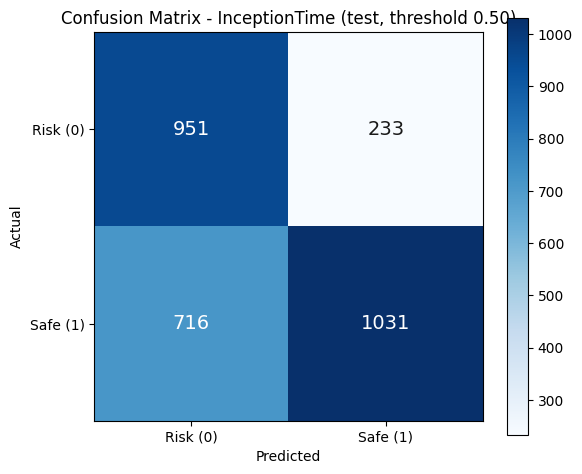

In [11]:
import matplotlib.pyplot as plt

# Confusion matrix at the default 0.5 threshold
y_pred_05 = (probs > 0.5).astype(int)
cm_arr = confusion_matrix(y_true, y_pred_05)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_arr, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Risk (0)', 'Safe (1)'])
ax.set_yticklabels(['Risk (0)', 'Safe (1)'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - InceptionTime (test, threshold 0.50)')

thresh = (cm_arr.max() + cm_arr.min()) / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_arr[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm_arr[i, j] > thresh else '#1a1a1a')

plt.tight_layout()
plt.show()


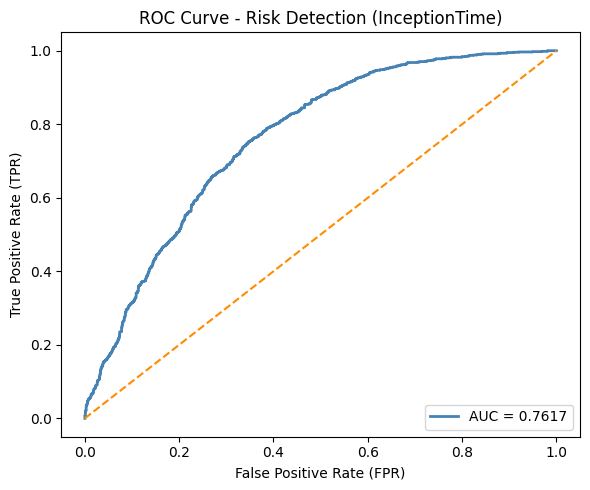

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC curve using P(at-risk) as the classifier score
fpr, tpr, _ = roc_curve(y_true, 1 - probs, pos_label=0)
auc_val = roc_auc_score(y_true, probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_val:.4f}')
ax.plot([0, 1], [0, 1], color='darkorange', linestyle='--', lw=1.5)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curve - Risk Detection (InceptionTime)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 6. Hyperparameter Search (Optuna)

This optional section searches for hyperparameters with Optuna using a TPE (Tree-structured
Parzen Estimator) sampler. Each trial trains a fresh model for a few epochs and reports its
validation ROC-AUC; a MedianPruner stops trials that fall below the running median at each
epoch to save GPU time.

### Search space

| Parameter | Range | Type |
|-----------|-------|------|
| `nf` (filters per block) | {32, 64, 96} | categorical |
| `depth` (inception modules) | 4, 6, 8 | integer, step 2 |
| `dropout` | 0.10 – 0.40 | float |
| `lr_max` | 5×10⁻⁵ – 5×10⁻⁴ | float, log scale |
| `weight_decay` | 1×10⁻⁵ – 1×10⁻³ | float, log scale |

The search is disabled by default. Set `RUN_OPTUNA = True` in the cell below to run it
(about 7 hours on a T4 GPU).

In [13]:
# Optuna hyperparameter search
# Set RUN_OPTUNA = True to execute. Results are printed per epoch as they complete
# and saved to /kaggle/working/optuna_results.json.

RUN_OPTUNA = False

if RUN_OPTUNA:
    try:
        import optuna
    except ImportError:
        import subprocess; subprocess.run(['pip', 'install', 'optuna', '-q'], check=True)
        import optuna
    import json as _json
    from optuna.samplers import TPESampler

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    OPTUNA_EPOCHS = 8     # short runs to rank configs; not full convergence
    N_TRIALS      = 15    # total trials; ~7h on T4 with no pruning

    def objective(trial):
        torch.manual_seed(SEED); np.random.seed(SEED)

        # Sample hyperparameters from the search space
        nf           = trial.suggest_categorical('nf',           [32, 64, 96])
        depth        = trial.suggest_int        ('depth',        4, 8, step=2)
        dropout      = trial.suggest_float      ('dropout',      0.10, 0.40)
        lr_max       = trial.suggest_float      ('lr_max',       5e-5, 5e-4, log=True)
        weight_decay = trial.suggest_float      ('weight_decay', 1e-5, 1e-3, log=True)

        # Build model, loss, optimiser, and scheduler for this trial
        m     = InceptionTime(c_in=15, c_out=2, nf=nf, depth=depth, dropout=dropout).to(device)
        _w    = torch.tensor([_n1 / _n0, 1.0], dtype=torch.float32).to(device)
        crit  = nn.CrossEntropyLoss(weight=_w)
        opt   = torch.optim.Adam(m.parameters(), lr=lr_max, weight_decay=weight_decay)
        sched = OneCycleLR(opt, max_lr=lr_max,
                           steps_per_epoch=len(train_dl), epochs=OPTUNA_EPOCHS)
        sc    = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

        best_roc_t = 0.0
        for epoch in range(OPTUNA_EPOCHS):
            # Train one epoch
            m.train()
            for xb, yb in train_dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    loss = crit(m(xb), yb)
                sc.scale(loss).backward()
                sc.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                sc.step(opt); sc.update(); sched.step()

            # Validate
            m.eval()
            vp, vt = [], []
            with torch.no_grad():
                for xb, yb in val_dl:
                    xb = xb.to(device)
                    with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                        logits = m(xb)
                    vp.append(torch.softmax(logits.float(), 1)[:, 1].cpu().numpy())
                    vt.append(yb.numpy())
            roc_t = roc_auc_score(np.concatenate(vt), np.concatenate(vp))
            best_roc_t = max(best_roc_t, roc_t)

            # Report to pruner
            trial.report(roc_t, epoch)
            if trial.should_prune():
                del m; gc.collect(); torch.cuda.empty_cache()
                raise optuna.exceptions.TrialPruned()

            print(f'  trial {trial.number:>2}  epoch {epoch+1:>2}  roc={roc_t:.4f}')

        del m; gc.collect(); torch.cuda.empty_cache()
        return best_roc_t

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    # Print results
    print(f'\nBest trial   : #{study.best_trial.number}')
    print(f'Best val ROC : {study.best_value:.4f}')
    print(f'Best params  : {study.best_params}')

    print(f'\n{"Trial":>6}  {"ROC-AUC":>8}  {"nf":>4}  {"depth":>6}  '
          f'{"dropout":>8}  {"lr_max":>10}  {"wd":>10}')
    print('-' * 65)
    for t in sorted(study.trials, key=lambda x: x.value or -1, reverse=True):
        if t.value is not None:
            p = t.params
            print(f'{t.number:>6}  {t.value:>8.4f}  {p["nf"]:>4}  {p["depth"]:>6}  '
                  f'{p["dropout"]:>8.3f}  {p["lr_max"]:>10.2e}  {p["weight_decay"]:>10.2e}')

    # Save results to JSON
    _results = {
        'best_value':  study.best_value,
        'best_trial':  study.best_trial.number,
        'best_params': study.best_params,
        'trials': [
            {'number': t.number, 'value': t.value or -1,
             'state': str(t.state), 'params': t.params}
            for t in study.trials
        ]
    }
    with open('/kaggle/working/optuna_results.json', 'w') as _f:
        _json.dump(_results, _f, indent=2)
    print('\nResults saved → /kaggle/working/optuna_results.json')

else:
    print("Optuna search is disabled (RUN_OPTUNA = False).")
    print("Set RUN_OPTUNA = True to run it (~7 hours on T4).")


Optuna search is disabled (RUN_OPTUNA = False).
Set RUN_OPTUNA = True to run it (~7 hours on T4).


## 7. Probability Output for Ensemble

Generates predicted probabilities for every flight across all three splits  
and saves them as a CSV for downstream model ensembling.

| Column | Description |
|--------|-------------|
| `Master_Index` | Flight identifier — matches the index of `labels.csv` |
| `split` | Dataset partition (`train`, `val`, or `test`) |
| `prob_at_risk` | P(class = 0) — model's probability that the flight is at-risk |
| `true_label` | Ground truth (0 = at-risk, 1 = safe) |

`prob_at_risk` is the value to use for ensembling: higher = more likely to need maintenance.

In [14]:
# Predicted P(at-risk) for every flight, averaged across the ensemble
def ensemble_prob_at_risk(loader):
    """Average P(at-risk) = softmax(logits)[:, 0] across all models, in loader order."""
    totals = None
    for m in models:
        chunks = []
        with torch.no_grad():
            for xb, _ in loader:
                logits = m(xb.to(device))
                chunks.append(torch.softmax(logits, dim=1)[:, 0].cpu().numpy())
        p = np.concatenate(chunks)
        totals = p if totals is None else totals + p
    return totals / len(models)

# Inference DataLoaders with shuffle=False so row order is fixed 
# torch.from_numpy() shares memory with the source array, so the tensors inside
# train_dl / val_dl remain valid via .dataset even after X_tr / X_vl were freed.

infer_train_dl = DataLoader(train_dl.dataset, batch_size=64, shuffle=False, num_workers=0)
infer_val_dl   = DataLoader(val_dl.dataset,   batch_size=64, shuffle=False, num_workers=0)

# Test set: rebuild from the float16 source (X_test was not deleted)
X_test_out    = X_test.transpose(0, 2, 1).astype(np.float32, order='C')
infer_test_dl = make_loader(X_test_out, y_test, batch_size=64, shuffle=False)

# Master Index for each split (same mask order as the sequences)
idx_train = idx_full[split_col == "train"]
idx_val   = idx_full[split_col == "val"]
idx_test_ = idx_full[split_col == "test"]

# Run inference
probs_train = ensemble_prob_at_risk(infer_train_dl)
probs_val   = ensemble_prob_at_risk(infer_val_dl)
probs_test  = ensemble_prob_at_risk(infer_test_dl)

# Assemble and save
df_out = pd.concat([
    pd.DataFrame({'Master_Index': idx_train, 'split': 'train',
                  'prob_at_risk': probs_train, 'true_label': y_train}),
    pd.DataFrame({'Master_Index': idx_val,   'split': 'val',
                  'prob_at_risk': probs_val,   'true_label': y_val}),
    pd.DataFrame({'Master_Index': idx_test_,  'split': 'test',
                  'prob_at_risk': probs_test,  'true_label': y_test}),
], ignore_index=True)

out_path = '/kaggle/working/inceptiontime_rul2d_probs.csv'
df_out.to_csv(out_path, index=False)

print(f"Saved {len(df_out):,} rows -> {out_path}")
print("\nColumn summary:")
print(df_out.groupby('split').agg(
    flights=('Master_Index', 'count'),
    at_risk=('true_label', lambda x: (x == 0).sum()),
    mean_prob_at_risk=('prob_at_risk', 'mean')
).round(4).to_string())
print("\nFirst 5 rows:")
print(df_out.head().to_string(index=False))

Saved 19,540 rows -> /kaggle/working/inceptiontime_rul2d_probs.csv

Column summary:
       flights  at_risk  mean_prob_at_risk
split                                     
test      2931     1184             0.5235
train    13678     5522             0.5262
val       2931     1183             0.5246

First 5 rows:
 Master_Index split  prob_at_risk  true_label
            1 train      0.620308           0
            7 train      0.512677           1
           11 train      0.507337           1
           17 train      0.611436           1
           18 train      0.480022           1
